# 02 · Limpieza de datos: qué columnas sobran y qué filas son ruido

Continuación de `01_exploracion_datos.ipynb`. Aquí buscamos **ruido que distorsionaría las features**, lo cuantificamos y decidimos qué hacer con cada caso.

**Criterios**
- **Quitar** solo lo que es claramente erróneo: importes a cero, duplicados de sincronización, outliers imposibles, documentos que no son facturas.
- **Marcar** (columna booleana) lo que es real pero no es negocio, o lo que es dudoso: traspasos internos, fechas incoherentes, meses con poca actividad. Así cada feature decide si lo usa, y la decisión se puede deshacer.
- **Sin mirar al futuro:** ninguna regla puede usar información posterior al mes que se está limpiando (excepto las que usan la fecha de extracción, que están señaladas).

Al final (sección 6) están las funciones `limpiar_transacciones()` y `limpiar_facturas()`, que aplican todas las reglas y devuelven un log de filas quitadas y marcadas.

**Índice**
1. Carga
2. Columnas que sobran
3. Transacciones: filas con ruido
4. Facturas: filas con ruido
5. Empresas y meses con pocos datos
6. Funciones de limpieza e impacto
7. Resumen de reglas

In [1]:
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "raw"          # CSV originales (ver docs/decisiones.md)
assert DATA.exists(), f"No encuentro {DATA}: coloca los CSV originales en data/raw/"
FECHA_EXTRACCION = pd.Timestamp("2026-09-01")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, GRID, MUTED = "#0b0b0b", "#52514e", "#e6e5e1", "#b9b8b2"
plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 100,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=PAL), "lines.linewidth": 2,
})

def pct(x):
    return f"{100 * x:.1f}%"

def load_transactions(path=DATA / "transactions.csv"):
    raw = path.read_bytes().replace(b"\x00", b"")          # quita los bytes NUL
    return pd.read_csv(io.BytesIO(raw), parse_dates=["date", "value_date"], low_memory=False)

## 1 · Carga

In [2]:
groups    = pd.read_csv(DATA / "groups.csv")
companies = pd.read_csv(DATA / "companies.csv", parse_dates=["created_at"])
banking   = pd.read_csv(DATA / "banking_products.csv", parse_dates=["created_at"])
debt      = pd.read_csv(DATA / "debt_products.csv", parse_dates=["created_at"])
schedule  = pd.read_csv(DATA / "debt_schedule_config.csv", parse_dates=["next_payment_date", "last_payment_date"])
balances  = pd.read_csv(DATA / "balances.csv", parse_dates=["date"])
invoices  = pd.read_csv(DATA / "invoices.csv", parse_dates=["issuance_date", "due_date", "payment_date"], low_memory=False)
tx        = load_transactions()

TABLAS = dict(groups=groups, companies=companies, banking_products=banking, debt_products=debt,
              debt_schedule_config=schedule, balances=balances, invoices=invoices, transactions=tx)
comp2grp = companies.set_index("company_id").group_id
tipo_producto = pd.concat([banking[["product_id", "type"]], debt[["product_id", "type"]]]).set_index("product_id").type
print({k: f"{len(v):,}" for k, v in TABLAS.items()})

{'groups': '250', 'companies': '1,286', 'banking_products': '5,987', 'debt_products': '2,239', 'debt_schedule_config': '87', 'balances': '7,996', 'invoices': '897,894', 'transactions': '2,556,437'}


## 2 · Columnas que sobran

Perfil de cada columna: tipo, % de nulos, nº de valores distintos y un ejemplo. Una columna es candidata a sobrar si está casi vacía, es constante, repite información de otra o no tiene relación posible con la salud financiera.

In [3]:
def perfil(df):
    return pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().mean().map(pct),
        "distintos": df.nunique(),
        "ejemplo": df.apply(lambda s: s.dropna().iloc[0] if s.notna().any() else None).astype(str).str[:40],
    })

for nombre, df in TABLAS.items():
    print(f"\n=== {nombre}")
    display(perfil(df))


=== groups


,tipo,nulos,distintos,ejemplo
group_id,str,0.0%,250,GROUP_0001
erp,str,64.4%,21,Netsuite
n_companies_in_sample,int64,0.0%,21,3



=== companies


,tipo,nulos,distintos,ejemplo
company_id,str,0.0%,1286,COMP_0218
group_id,str,0.0%,250,GROUP_0113
country,str,82.1%,22,ES
currency,str,0.0%,28,EUR
erp,str,42.1%,20,businessOne
created_at,datetime64[us],0.0%,1286,2025-03-07 12:27:13



=== banking_products


...

,tipo,nulos,distintos,ejemplo
product_id,str,0.0%,7996,PRODUCT_03496
company_id,str,0.0%,1273,COMP_0001
date,datetime64[us],0.0%,5,2026-09-01 00:00:00
balance,float64,0.0%,5401,31795.29
available,float64,100.0%,0,NaN
granted,float64,66.9%,1007,-2000.0
liquidity,float64,76.3%,1084,926103.68
countable,float64,91.7%,514,926103.68



=== invoices


,tipo,nulos,distintos,ejemplo
operation_id,str,0.0%,897894,00229f2507386496cf94639ebac785f3
company_id,str,0.0%,785,COMP_0556
document_type,str,0.0%,10,invoice
issuance_date,datetime64[us],0.0%,12704,2025-11-29 00:00:00
due_date,datetime64[us],0.0%,13586,2025-12-29 00:00:00
payment_date,datetime64[us],0.0%,15398,2025-12-29 00:00:00
amount,float64,0.0%,318255,-720.0
pending_amount,float64,0.0%,115814,0.0
currency,str,0.0%,39,SEK
accounting_currency,str,0.0%,23,DKK



=== transactions


,tipo,nulos,distintos,ejemplo
transaction_id,str,0.0%,2556437,031b6af5e65957a71747a25f819ee269
company_id,str,0.0%,1286,COMP_0194
product_id,str,0.0%,5311,PRODUCT_00121
date,datetime64[us],0.0%,71456,2025-02-15 00:00:00
value_date,datetime64[us],0.0%,105097,2025-02-15 00:00:00
amount,float64,0.0%,763006,-12.0
exchange_rate,float64,0.0%,2224,1.0
status,str,1.2%,2,booked
accounting_status,str,61.6%,6,RECONCILIATION_COMPLETED
category,str,0.0%,23,interest_charge


In [4]:
# Comprobaciones concretas que justifican las decisiones de la tabla de abajo
print("balances.available 100% nulo:", balances.available.isna().all())
print("balances.countable == balance cuando existe:",
      pct(np.isclose(balances.countable, balances.balance)[balances.countable.notna()].mean()))
print("banking.label solo es tipo + número:", banking.label.str.match(r"^[A-Z_]+_\d+$").mean() == 1)
print("service: nº de bank_name distintos por código (mediana):", banking.groupby("service").bank_name.nunique().median(),
      "| ejemplos:", banking[["service", "bank_name"]].drop_duplicates().head(3).values.tolist())
print("value_date fuera de [2024-06, 2027]:", ((tx.value_date < "2024-06-01") | (tx.value_date > "2027-01-01")).sum())
print("value_date == date:", pct((tx.value_date.dt.normalize() == tx.date.dt.normalize()).mean()))
print("schedule: amortization_type constante:", schedule.amortization_type.nunique() == 1)
print("companies.erp distinto de groups.erp en", pct((companies.erp.fillna("-") != companies.group_id.map(groups.set_index("group_id").erp).fillna("-")).mean()),
      "(vocabularios distintos, p. ej. 'businessCentral' vs 'Microsoft Business Central')")

balances.available 100% nulo: True
balances.countable == balance cuando existe: 56.3%
banking.label solo es tipo + número: True
service: nº de bank_name distintos por código (mediana): 1.0 | ejemplos: [['sabadell_emp', 'Banco Sabadell Empresas'], ['santander_emp', 'Banco Santander'], ['ibercaja', 'iberCaja']]
value_date fuera de [2024-06, 2027]: 243
value_date == date: 88.5%
schedule: amortization_type constante: True
companies.erp distinto de groups.erp en 67.2% (vocabularios distintos, p. ej. 'businessCentral' vs 'Microsoft Business Central')


**Decisión por columna** (solo se listan las que sobran o cambian de uso; el resto se queda):

| tabla | columna | decisión | motivo |
|---|---|---|---|
| `companies` | `country` | **quitar** | 82% nulo y valores sin normalizar (`ES`, `ESPAÑA`, `Espanya`) |
| `companies`, `groups` | `erp` | solo contexto | describe el software, no la salud. Además, los dos ficheros usan vocabularios distintos |
| `companies` | `created_at` | solo para cobertura | es la fecha de alta en Embat. Como feature del score, el modelo aprendería la antigüedad del cliente |
| `banking_products`, `debt_products` | `label`, `service` | **quitar** | `label` es solo tipo + número. `service` es el código técnico del conector bancario (p. ej. `sabadell_emp`) y no aporta nada que no dé `bank_name` |
| `balances` | `available` | **quitar** | 100% nulo |
| `balances` | `countable`, `liquidity`, `granted` | **quitar** | 67–92% nulos y su significado depende del banco (`countable` solo coincide con `balance` en la mitad de los casos). `granted` ya está en `debt_products` |
| `transactions` | `value_date` | **quitar** | basura (2099-12-31) y casi siempre igual a `date` |
| `transactions` | `accounting_status` | **quitar del score** | es el estado de conciliación en Embat (flujo de trabajo del contable), no un hecho financiero. Un `DISCARDED` no significa que el movimiento no exista |
| `transactions` | `exchange_rate` | mantener | necesaria para pasar las cuentas en otra moneda a EUR (ver 3.6) |
| `transactions` | `counterparty_id` | mantener, sin features | 90% nulo en transacciones. Las contrapartes se sacan de facturas |
| `invoices` | `accounting_currency`, `exchange_rate` | mantener | para convertir a EUR |
| `invoices` | `concept` | mantener solo para deduplicar | texto libre anonimizado, casi sin señal |
| `debt_schedule_config` | `amortization_type` | **quitar** | constante (`constant quote`) |

## 3 · Transacciones: filas con ruido

### 3.1 · Importe cero y producto desconocido

In [5]:
cero = tx.amount == 0
sin_producto = ~tx.product_id.isin(tipo_producto.index)
print(f"amount == 0: {cero.sum():,} filas")
print(f"product_id que no está en banking ni en debt: {sin_producto.sum():,} filas en {tx[sin_producto].company_id.nunique()} empresas")
tx[sin_producto][["company_id", "product_id", "date", "amount", "category", "description"]].head()

amount == 0: 369 filas
product_id que no está en banking ni en debt: 1,314 filas en 14 empresas


,company_id,product_id,date,amount,category,description
1621,COMP_1115,PRODUCT_08229,2025-12-29,"30,000.00",payment_refund,devolucion anticipo COUNTERPARTY_29397 mondragon
4335,COMP_1115,PRODUCT_08229,2026-03-02,"1,218,386.17",-,cobro COUNTERPARTY_56802
4341,COMP_0046,PRODUCT_08230,2026-06-05,-26.97,-,RECIB/COUNTERPARTY_05039 S.
7850,COMP_1115,PRODUCT_08229,2026-03-10,"-91,093.76",-,pago [X]
8212,COMP_1115,PRODUCT_08229,2026-01-12,"-41,206.33",-,pago UR Global


**Decisión: quitar ambas.** Un movimiento de 0 € no aporta nada. Un movimiento en una cuenta desconocida no se puede tipificar ni cuadrar con ningún saldo. En total son menos de 2 K filas.

### 3.2 · Outliers extremos

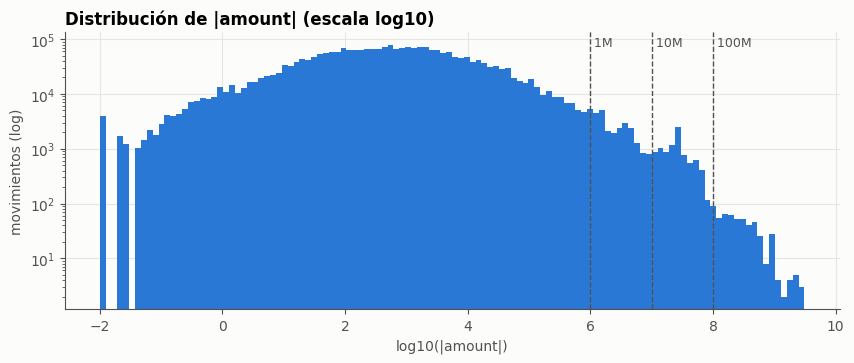

|amount| >     1,000,000: 35,128 filas |  410 empresas | 92.7% del importe entrante total
|amount| >    10,000,000:  9,420 filas |   95 empresas | 80.8% del importe entrante total
|amount| >   100,000,000:    491 filas |   22 empresas | 38.2% del importe entrante total


In [6]:
absa = tx.amount.abs()
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(np.log10(absa[absa > 0]), bins=120, color=PAL[0])
for thr, lab in [(1e6, "1M"), (1e7, "10M"), (1e8, "100M")]:
    ax.axvline(np.log10(thr), color=INK2, lw=1, ls="--")
    ax.text(np.log10(thr), ax.get_ylim()[1] * 0.9, f" {lab}", color=INK2, fontsize=9)
ax.set_yscale("log")
ax.set_title("Distribución de |amount| (escala log10)")
ax.set_xlabel("log10(|amount|)"); ax.set_ylabel("movimientos (log)")
plt.show()

for thr in [1e6, 1e7, 1e8]:
    m = absa > thr
    print(f"|amount| > {thr:>13,.0f}: {m.sum():6,d} filas | {tx[m].company_id.nunique():4d} empresas | "
          f"{pct(tx.amount[m & (tx.amount > 0)].sum() / tx.amount[tx.amount > 0].sum())} del importe entrante total")

In [7]:
big = tx[absa > 1e8]
print("Empresas con más outliers > 100M:", big.company_id.value_counts().head(5).to_dict())
print("Categoría:", big.category.value_counts().head(4).to_dict())
print("¿Se compensan? suma neta / suma absoluta =", round(big.amount.sum() / big.amount.abs().sum(), 2))

# Criterio relativo: importe desproporcionado para la propia empresa
p99 = tx.groupby("company_id").amount.transform(lambda s: s.abs().quantile(0.99))
rel = absa > 20 * p99
print(f"Movimientos > 20 × p99 de su empresa: {rel.sum():,} (de ellos > 100M: {(rel & (absa > 1e8)).sum()})")

Empresas con más outliers > 100M: {'COMP_0900': 109, 'COMP_1192': 63, 'COMP_0629': 56, 'COMP_0306': 53, 'COMP_0487': 51}
Categoría: {'-': 318, 'collection': 68, 'payment': 41, 'utility': 29}
¿Se compensan? suma neta / suma absoluta = 0.18
Movimientos > 20 × p99 de su empresa: 255 (de ellos > 100M: 9)


- Hay 491 movimientos de más de 100 M€, concentrados en 22 empresas y casi todos sin categoría. Suponen **el 38% de todo el importe entrante**. No son flujos de negocio de una pyme: son traspasos de tesorería, operaciones financieras o errores de carga.
- El umbral absoluto de 100 M€ es conservador. Por debajo hay importes grandes que pueden ser reales para empresas grandes; eso lo resuelve el criterio relativo (**más de 20 veces el p99 de la propia empresa**).

**Decisión:** **quitar** los de más de 100 M€ y **marcar** (`es_outlier`) los que superan 20 × p99 de su empresa. Las features de flujo ignoran los marcados y las winsorizan. Ojo: al quitar filas, la reconstrucción del saldo hacia atrás de esas 22 empresas deja de cuadrar. Para ellas, el saldo reconstruido no es fiable en ningún caso.

### 3.3 · Duplicados: legítimos frente a meses duplicados por la sincronización

In [8]:
clave = ["company_id", "product_id", "date", "amount", "description"]
tx["en_duplicado"] = tx.duplicated(clave, keep=False)
print(f"Filas que forman parte de un grupo duplicado: {tx.en_duplicado.sum():,} ({pct(tx.en_duplicado.mean())})")
print("Tamaño de los grupos:", tx[tx.en_duplicado].groupby(clave).size().value_counts().head(5).to_dict())
print("|amount| mediano en duplicados:", tx.amount[tx.en_duplicado].abs().median(), "vs global:", tx.amount.abs().median())

Filas que forman parte de un grupo duplicado: 168,599 (6.6%)
Tamaño de los grupos: {2: 41023, 3: 8061, 4: 2754, 5: 1229, 6: 943}
|amount| mediano en duplicados: 83.38 vs global: 525.0


¿Son errores? No necesariamente. La descripción está **anonimizada**, así que dos pagos distintos del mismo importe el mismo día ("2 × comisión de 5 €", "TRANSFERENCIA A [COMPANY]") quedan idénticos. Son importes pequeños, típicos de comisiones y pagos recurrentes. La pista está en **cómo se reparten por empresa y mes**:

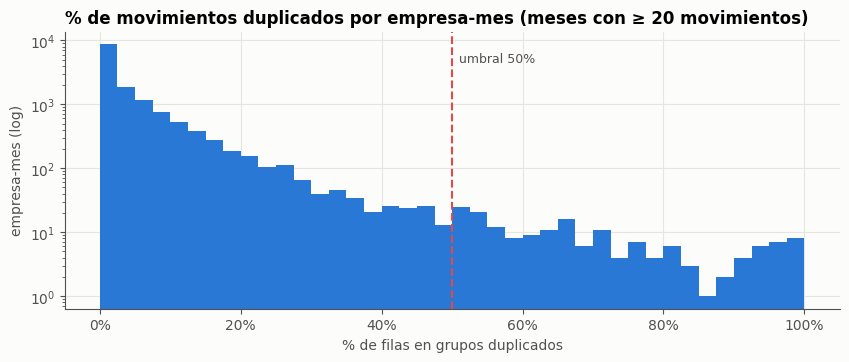

Empresa-mes con ≥ 50% duplicado: 171 en 86 empresas (53,778 filas)

Ejemplo COMP_1031, % duplicado por mes:


mes,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
pct_dup,71.4%,70.1%,68.9%,66.7%,72.2%,66.7%,66.7%,71.8%,80.6%,66.7%,67.0%,66.7%,75.0%,72.2%,53.8%,0.0%,25.0%,0.0%


In [9]:
tx["mes"] = tx.date.dt.to_period("M")
dm = tx.groupby(["company_id", "mes"]).agg(n=("amount", "size"), pct_dup=("en_duplicado", "mean"))
dm = dm[dm.n >= 20]

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(dm.pct_dup, bins=np.arange(0, 1.02, 0.025), color=PAL[0])
ax.axvline(0.5, color=PAL[7], lw=1.5, ls="--")
ax.text(0.51, ax.get_ylim()[1] * 0.5, "umbral 50%", color=INK2, fontsize=9)
ax.set_yscale("log")
ax.set_title("% de movimientos duplicados por empresa-mes (meses con ≥ 20 movimientos)")
ax.set_xlabel("% de filas en grupos duplicados"); ax.set_ylabel("empresa-mes (log)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.show()

malos = dm[dm.pct_dup >= 0.5]
print(f"Empresa-mes con ≥ 50% duplicado: {len(malos)} en {malos.index.get_level_values(0).nunique()} empresas "
      f"({malos.n.sum():,} filas)")
ej = malos.index.get_level_values(0).value_counts().index[0]
print(f"\nEjemplo {ej}, % duplicado por mes:")
dm.loc[ej].pct_dup.map(pct).to_frame().T

La mayoría de empresa-mes tienen menos del 10% de filas duplicadas, lo normal. Hay una cola de meses con más del 50%, en algunos casos hasta el 97%: son **meses enteros cargados dos veces** al conectar o resincronizar el banco. En el ejemplo, el problema empieza y termina en meses concretos, algo típico de un fallo de sincronización y no del negocio.

**Decisión:** en los empresa-mes con ≥ 50% de filas duplicadas, **quitar las repeticiones** (conservar la primera). En el resto, **no tocar**: los duplicados sueltos son probablemente pagos reales repetidos.

### 3.4 · Movimientos `pending` que ya están como `booked`

In [10]:
print("status:", tx.status.value_counts(dropna=False).to_dict())
k2 = ["company_id", "product_id", "amount", "description"]
pend = tx[tx.status == "pending"].reset_index()
book = tx[tx.status == "booked"][k2 + ["date"]]
m = pend.merge(book, on=k2, suffixes=("", "_b"))
gemelo = m.loc[(m.date_b - m.date).dt.days.abs() <= 5, "index"].unique()
print(f"pending con un gemelo booked (mismo importe y concepto, ±5 días): {len(gemelo):,} de {len(pend):,}")
print("status nulo concentrado en", tx[tx.status.isna()].company_id.nunique(), "empresas:",
      tx[tx.status.isna()].company_id.value_counts().head(3).to_dict())

status: {'booked': 2520019, nan: 29839, 'pending': 6579}
pending con un gemelo booked (mismo importe y concepto, ±5 días): 1,780 de 6,579
status nulo concentrado en 44 empresas: {'COMP_1187': 4234, 'COMP_0404': 3349, 'COMP_0252': 3022}


Un movimiento `pending` es provisional. Cuando el banco lo asienta, aparece otra vez como `booked`. Si se quedan los dos, se cuenta doble.

**Decisión:** **quitar los `pending` que tienen gemelo `booked`**. Los `pending` sin gemelo se quedan (son recientes o nunca se asentaron). El `status` nulo afecta a empresas enteras (depende del banco o el conector), no es un problema del movimiento, así que se queda.

### 3.5 · Traspasos internos (espejos)

Mover dinero de una cuenta propia a otra genera **dos movimientos**: −X en una cuenta y +X en otra, el mismo día. No es negocio, pero infla las entradas y las salidas brutas. Pasa lo mismo entre empresas de un mismo grupo.

In [11]:
def marcar_espejos(t, nivel):
    """Empareja +X / −X del mismo día y el mismo `nivel` (company_id o group_id) en cuentas/empresas distintas.
    Empareja 1 a 1 (cumcount), así que un importe repetido no se empareja varias veces."""
    d = t[["transaction_id", "company_id", "product_id", "amount"]].copy()
    d["dia"] = t.date.dt.normalize()
    d["nivel"] = t.company_id if nivel == "company_id" else t.company_id.map(comp2grp)
    d["abs"] = d.amount.abs()
    d = d[d.amount != 0]
    d["k"] = d.groupby(["nivel", "dia", "abs", np.sign(d.amount)]).cumcount()
    pos, neg = d[d.amount > 0], d[d.amount < 0]
    mm = pos.merge(neg, on=["nivel", "dia", "abs", "k"], suffixes=("_p", "_n"))
    distinto = mm.product_id_p != mm.product_id_n if nivel == "company_id" else mm.company_id_p != mm.company_id_n
    mm = mm[distinto]
    return t.transaction_id.isin(pd.concat([mm.transaction_id_p, mm.transaction_id_n]))

tx["es_traspaso_interno"] = marcar_espejos(tx, "company_id")
tx["es_intragrupo"] = marcar_espejos(tx, "group_id") & ~tx.es_traspaso_interno

entradas = tx.amount > 0
for col in ["es_traspaso_interno", "es_intragrupo"]:
    print(f"{col:22s}: {tx[col].sum():8,d} filas | {pct(tx.amount[tx[col] & entradas].sum() / tx.amount[entradas].sum())} "
          f"del importe entrante | categorías: {tx[tx[col]].category.value_counts(normalize=True).head(3).round(2).to_dict()}")

es_traspaso_interno   :   63,642 filas | 13.9% del importe entrante | categorías: {'transfer': 0.36, 'collection': 0.24, 'payment': 0.19}
es_intragrupo         :   90,140 filas | 9.1% del importe entrante | categorías: {'transfer': 0.35, 'collection': 0.2, 'payment': 0.2}


**Decisión: marcar, no quitar.**
- A nivel de empresa, los traspasos internos suman cero en el neto, pero **no deben contar como entradas ni salidas** (ni como "cobros"). Y son necesarios para reconstruir el saldo de cada cuenta.
- Los movimientos **intragrupo** son flujos reales para cada empresa, pero **desaparecen al agregar por grupo**. Si el leaderboard puntúa por grupo, hay que excluirlos de los flujos del grupo.
- Fíjate en que muchos espejos están categorizados como `collection` o `payment`. Por eso la categoría sola no basta para separar negocio de tesorería.

### 3.6 · Moneda

In [12]:
ccy = tx.product_id.map(pd.concat([banking.set_index("product_id").currency, debt.set_index("product_id").currency]))
print("Movimientos en cuentas no EUR:", pct((ccy != "EUR").mean()))
print("exchange_rate != 1 según moneda de la cuenta:", tx[tx.exchange_rate != 1].groupby(ccy).size().sort_values(ascending=False).head(6).to_dict())

Movimientos en cuentas no EUR: 9.8%
exchange_rate != 1 según moneda de la cuenta: {'USD': 55165, 'GBP': 14859, 'EUR': 10312, 'BRL': 6101, 'CLP': 3740, 'ARS': 1753}


Alrededor del 10% de los movimientos está en cuentas en otra moneda, pero también hay ~10 K movimientos en cuentas **EUR** con `exchange_rate != 1` (pagos internacionales cobrados en EUR). Con los datos no se puede verificar al 100% si `amount` va en la moneda de la cuenta o en la original.

**Decisión:** para empezar, trabajar con **ratios dentro de cada empresa** (que no dependen de la moneda). Solo cuando haya que sumar entre empresas (agregación por grupo), convertir a EUR usando la moneda de la cuenta. Es una pregunta para hacer a Embat.

### 3.7 · Tipificación: separar negocio, tesorería y deuda

No es quitar filas: es añadir una columna `bloque` que dice para qué sirve cada movimiento en las features.

In [13]:
BLOQUES = {
    "entrada_operativa": ["collection", "bulk_collection", "pos_settlement", "cash_settlement", "cash_settlements"],
    "salida_operativa":  ["payment", "bulk_payment", "utility", "pos_withdrawal", "cash_withdrawal"],
    "gasto_fijo":        ["salary", "social_security", "tax"],
    "deuda":             ["debt_repayment", "interest_charge"],
    "coste_bancario":    ["fee"],
    "devolucion":        ["collection_refund", "payment_refund", "tax_refund"],
    "inversion":         ["investment_deployment", "investment_return"],
    "tesoreria":         ["transfer"],
}
cat2bloque = {c: b for b, cats in BLOQUES.items() for c in cats}

def bloque(t):
    b = t.category.map(cat2bloque).fillna("sin_categoria")
    b = b.mask(t.es_traspaso_interno, "traspaso_interno")
    return b

tx["bloque"] = bloque(tx)
res = tx.groupby("bloque").agg(filas=("amount", "size"),
                               entradas=("amount", lambda s: s[s > 0].sum()),
                               salidas=("amount", lambda s: -s[s < 0].sum()))
res["% entradas"] = (res.entradas / res.entradas.sum()).map(pct)
res.sort_values("filas", ascending=False)

,filas,entradas,salidas,% entradas
bloque,,,,
entrada_operativa,712409,"89,115,168,000.67","2,353.43",31.9%
salida_operativa,670510,0.00,"99,558,972,480.54",0.0%
sin_categoria,627085,"106,902,978,441.62","93,717,224,890.64",38.3%
coste_bancario,179353,"5,816.75","354,702,580.34",0.0%
tesoreria,128878,"42,288,364,569.57","28,258,860,810.09",15.1%
gasto_fijo,121858,"221,828,908.06","6,365,169,300.47",0.1%
traspaso_interno,63642,"38,742,065,745.13","38,742,065,745.13",13.9%
deuda,30606,0.00,"3,122,409,728.28",0.0%
devolucion,14962,"1,464,446,283.79","119,318,267.11",0.5%


`sin_categoria` sigue siendo un bloque grande. No se quita, pero **no cuenta como entrada ni salida operativa**. Si hace falta más cobertura, se puede recategorizar con reglas sobre `description` (por ejemplo, `TRASPASO`, `NOMINA`, `SEPA`); lo dejamos como mejora.

## 4 · Facturas: filas con ruido

### 4.1 · Importe cero, canceladas y tipos de documento

In [14]:
print(f"amount == 0: {(invoices.amount == 0).sum():,} | status cancel: {(invoices.status == 'cancel').sum():,}")
tipos = invoices.groupby("document_type").agg(
    n=("amount", "size"), importe_mediano=("amount", lambda s: s.abs().median()),
    pct_paid=("status", lambda s: (s == "paid").mean()), pct_ar=("amount", lambda s: (s > 0).mean()))
tipos.sort_values("n", ascending=False)

amount == 0: 1,183 | status cancel: 13,699


,n,importe_mediano,pct_paid,pct_ar
document_type,,,,
invoice,760406,675.00,0.73,0.41
paymentDocument,53761,633.27,0.79,0.32
note,38154,557.00,0.81,0.47
deposit,21390,175.00,0.90,0.55
invoiceGroup,13775,"2,306.15",0.66,0.33
deliveryNote,6380,83.93,0.29,0.66
refund,2018,372.62,0.90,0.46
purchaseOrder,1259,359.10,0.04,0.06
other,739,217.04,0.06,0.50


| tipo | decisión | motivo |
|---|---|---|
| `invoice`, `invoiceGroup` | **factura** | es lo que genera derechos de cobro y obligaciones de pago |
| `note`, `refund` | **abono** | rectificativas: restan de la facturación, pero no entran en retrasos ni morosidad |
| `deliveryNote`, `purchaseOrder` | **quitar** | albaranes y pedidos: todavía no son una obligación de pago |
| `paymentDocument`, `deposit`, `other`, `cheque` | **marcar como dudoso** | pueden ser el pago de una factura que ya está en la tabla (contaría doble). Fuera de las métricas de facturación y plazos |
| `status == cancel` | **quitar** | una factura anulada no existe a efectos financieros |
| `amount == 0` | **quitar** | |

### 4.2 · Facturas duplicadas

In [15]:
clave_f = ["company_id", "counterparty_id", "document_type", "issuance_date", "due_date", "amount", "concept"]
dup_f = invoices.duplicated(clave_f)
print(f"Duplicados exactos (misma empresa, contraparte, fechas, importe y concepto): {dup_f.sum():,}")
por_emp = dup_f.groupby(invoices.company_id).mean().sort_values(ascending=False)
print("Empresas con más duplicados:", por_emp.head(5).map(pct).to_dict())
print("Empresas con > 20% duplicado:", (por_emp > 0.2).sum())

Duplicados exactos (misma empresa, contraparte, fechas, importe y concepto): 20,708
Empresas con más duplicados: {'COMP_0542': '74.5%', 'COMP_1243': '70.7%', 'COMP_0433': '45.0%', 'COMP_1070': '35.4%', 'COMP_0226': '31.7%'}
Empresas con > 20% duplicado: 7


Aquí la clave incluye la contraparte y el concepto, así que es mucho más estricta que en las transacciones: dos facturas distintas a la vez del mismo proveedor, mismo importe, mismas fechas y mismo concepto es muy improbable. Además, se concentran en unas pocas empresas (sincronizaciones del ERP repetidas).

**Decisión: quitar las repeticiones exactas.**

### 4.3 · Fechas imposibles e incoherentes

In [16]:
plazo = (invoices.due_date - invoices.issuance_date).dt.days
retraso = (invoices.payment_date - invoices.due_date).dt.days
paid = invoices.status == "paid"
anomalias = pd.Series({
    "vencimiento anterior a la emisión": (plazo < 0).sum(),
    "plazo > 365 días": (plazo > 365).sum(),
    "vencimiento fuera de 2020–2030": ((invoices.due_date.dt.year < 2020) | (invoices.due_date.dt.year > 2030)).sum(),
    "paid con fecha de pago posterior a la extracción": (paid & (invoices.payment_date > FECHA_EXTRACCION + pd.Timedelta(days=1))).sum(),
    "paid con pago antes de la emisión": (paid & (invoices.payment_date < invoices.issuance_date)).sum(),
    "paid con retraso > 365 días": (paid & (retraso > 365)).sum(),
    "pending con vencimiento de hace > 30 días": ((invoices.status == "pending") & (invoices.due_date < FECHA_EXTRACCION - pd.Timedelta(days=30))).sum(),
    "overdue/pending: payment_date = relleno (= due_date)": (invoices.status.isin(["overdue", "pending"]) & (invoices.payment_date == invoices.due_date)).sum(),
}, name="facturas")
anomalias.to_frame()

,facturas
vencimiento anterior a la emisión,20869
plazo > 365 días,1476
vencimiento fuera de 2020–2030,199
paid con fecha de pago posterior a la extracción,18265
paid con pago antes de la emisión,19095
paid con retraso > 365 días,2100
pending con vencimiento de hace > 30 días,3127
overdue/pending: payment_date = relleno (= due_date),214664


**Decisiones (marcar, no quitar: la factura existe aunque sus fechas estén mal):**
- `fechas_validas = False` si el vencimiento es anterior a la emisión, el plazo supera 365 días o el vencimiento cae fuera de 2020–2030. Estas facturas cuentan para la facturación, pero **no para plazos ni retrasos**.
- **`payment_date_limpia`**: vacía (NaN) si la factura no está `paid` (el valor era un relleno) o si la fecha de pago es posterior a la extracción, algo imposible.
- **Pago antes de la emisión:** puede ser un anticipo real, así que se deja, pero el retraso se recorta (clip entre −60 y 365 días).
- **`status_limpio`**: un `pending` vencido hace más de 30 días se trata como `overdue`.

Recordatorio del notebook 01: `status` es una foto a la fecha de extracción. Estas correcciones no lo convierten en histórico. Para el mes *t* hay que usar `facturas_abiertas()`.

## 5 · Empresas y meses con pocos datos

Aquí no se quitan filas. Lo que se decide es **qué observaciones (empresa-mes) son fiables** para calcular features y para entrenar.

In [17]:
txv = tx[tx.date < FECHA_EXTRACCION]
movs = txv.groupby(["company_id", "mes"]).size().unstack()
activos = movs.notna()
dentro = activos.cummax(axis=1) & activos.iloc[:, ::-1].cummax(axis=1).iloc[:, ::-1]   # entre 1er y último mes con datos
hueco = dentro & ~activos

resumen = pd.Series({
    "empresas": len(movs),
    "empresas con < 6 meses de datos": (activos.sum(axis=1) < 6).sum(),
    "empresas con < 50 movimientos en total": (movs.sum(axis=1) < 50).sum(),
    "empresas con huecos (meses vacíos en medio)": (hueco.sum(axis=1) > 0).sum(),
    "empresa-mes con datos": int(activos.sum().sum()),
    "empresa-mes con < 5 movimientos": int((movs < 5).sum().sum()),
    "empresa-mes vacíos en medio de la historia": int(hueco.sum().sum()),
    "empresas cuyo último dato es anterior a 2026-06": int((activos.iloc[:, ::-1].idxmax(axis=1) < pd.Period("2026-06", "M")).sum()),
}, name="n")
resumen.to_frame()

,n
empresas,1286
empresas con < 6 meses de datos,8
empresas con < 50 movimientos en total,71
empresas con huecos (meses vacíos en medio),114
empresa-mes con datos,21313
empresa-mes con < 5 movimientos,2285
empresa-mes vacíos en medio de la historia,408
empresas cuyo último dato es anterior a 2026-06,62


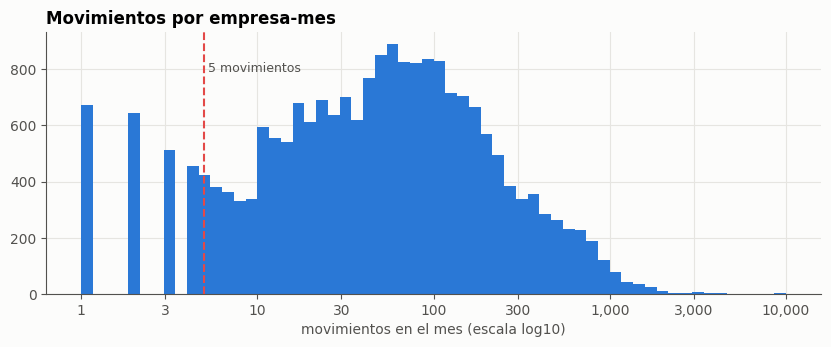

In [18]:
n_mes = movs.stack()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(np.log10(n_mes), bins=60, color=PAL[0])
ax.axvline(np.log10(5), color=PAL[7], lw=1.5, ls="--")
ax.text(np.log10(5), ax.get_ylim()[1] * 0.85, " 5 movimientos", color=INK2, fontsize=9)
ax.set_title("Movimientos por empresa-mes")
ax.set_xlabel("movimientos en el mes (escala log10)")
ticks = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000]
ax.set_xticks(np.log10(ticks), [f"{v:,}" for v in ticks])
plt.show()

**Decisiones:**
- **Meses anteriores al primer dato o posteriores al último:** fuera del panel (NaN, no cero).
- **Meses vacíos en medio de la historia:** probablemente desconexiones del banco. NaN y flag `hueco`, no "cero actividad".
- **Empresa-mes con < 5 movimientos:** flag `mes_fino`. Sus ratios (entradas/salidas, % por bloque) son muy ruidosos: mejor usar ventanas de 3 meses o no calcularlos ese mes.
- **Empresas con < 6 meses de datos:** no dan para features de dinámica (pendientes a 6 meses). Se pueden puntuar solo con nivel y conviene **excluirlas del entrenamiento**.
- **Empresas que dejan de tener datos antes del final:** a confirmar con Embat (¿cese o baja en la plataforma?).

## 6 · Funciones de limpieza e impacto

Juntamos todas las reglas en dos funciones que devuelven la tabla limpia y un log. Están pensadas para moverlas tal cual a un módulo (`src/limpieza.py`) cuando montemos el pipeline de features.

In [19]:
def limpiar_transacciones(tx, tipo_producto, umbral_abs=1e8, factor_p99=20, umbral_mes_dup=0.5):
    """Devuelve (transacciones limpias, log). Quita ruido y añade columnas:
    es_outlier, es_traspaso_interno, es_intragrupo, bloque, mes."""
    log = []
    t = tx.copy()
    t["mes"] = t.date.dt.to_period("M")

    def quitar(regla, mask):
        nonlocal t
        log.append({"tabla": "transactions", "regla": regla, "acción": "quitar", "filas": int(mask.sum())})
        t = t[~mask]

    def marcar(regla, col, mask):
        t[col] = mask
        log.append({"tabla": "transactions", "regla": regla, "acción": f"marcar ({col})", "filas": int(mask.sum())})

    quitar("amount == 0", t.amount == 0)
    quitar("producto desconocido", ~t.product_id.isin(tipo_producto.index))
    quitar(f"|amount| > {umbral_abs:,.0f}", t.amount.abs() > umbral_abs)

    clave = ["company_id", "product_id", "date", "amount", "description"]
    en_dup = t.duplicated(clave, keep=False)
    pct_dup = en_dup.groupby([t.company_id, t.mes]).transform("mean")
    n_mes = t.groupby(["company_id", "mes"]).amount.transform("size")
    quitar(f"repetición en empresa-mes con ≥ {umbral_mes_dup:.0%} duplicado",
           t.duplicated(clave, keep="first") & (pct_dup >= umbral_mes_dup) & (n_mes >= 20))

    k2 = ["company_id", "product_id", "amount", "description"]
    pend = t[t.status == "pending"].reset_index()
    m = pend.merge(t[t.status == "booked"][k2 + ["date"]], on=k2, suffixes=("", "_b"))
    quitar("pending con gemelo booked (±5 días)", t.index.isin(m.loc[(m.date_b - m.date).dt.days.abs() <= 5, "index"]))

    p99 = t.groupby("company_id").amount.transform(lambda s: s.abs().quantile(0.99))
    marcar(f"|amount| > {factor_p99} × p99 de la empresa", "es_outlier", t.amount.abs() > factor_p99 * p99)
    marcar("espejo +X/−X entre cuentas de la empresa", "es_traspaso_interno", marcar_espejos(t, "company_id"))
    marcar("espejo +X/−X entre empresas del grupo", "es_intragrupo", marcar_espejos(t, "group_id") & ~t.es_traspaso_interno)
    t["bloque"] = bloque(t)
    t = t.drop(columns=["value_date", "accounting_status", "en_duplicado"], errors="ignore")
    return t, pd.DataFrame(log)


def limpiar_facturas(invoices, fecha_extraccion=FECHA_EXTRACCION):
    """Devuelve (facturas limpias, log). Añade: clase (factura/abono/dudoso), fechas_validas,
    payment_date_limpia, status_limpio, retraso_dias, plazo_dias."""
    log = []
    f = invoices.copy()

    def quitar(regla, mask):
        nonlocal f
        log.append({"tabla": "invoices", "regla": regla, "acción": "quitar", "filas": int(mask.sum())})
        f = f[~mask]

    def marcar(regla, col, mask):
        log.append({"tabla": "invoices", "regla": regla, "acción": f"marcar ({col})", "filas": int(mask.sum())})

    quitar("amount == 0", f.amount == 0)
    quitar("status cancel", f.status == "cancel")
    quitar("albarán o pedido (deliveryNote, purchaseOrder)", f.document_type.isin(["deliveryNote", "purchaseOrder"]))
    quitar("duplicado exacto", f.duplicated(["company_id", "counterparty_id", "document_type", "issuance_date",
                                             "due_date", "amount", "concept"]))

    f["clase"] = np.select([f.document_type.isin(["invoice", "invoiceGroup"]), f.document_type.isin(["note", "refund"])],
                           ["factura", "abono"], "dudoso")
    marcar("paymentDocument, deposit, other, cheque", "clase = dudoso", f.clase == "dudoso")

    f["plazo_dias"] = (f.due_date - f.issuance_date).dt.days
    f["fechas_validas"] = f.plazo_dias.between(0, 365) & f.due_date.dt.year.between(2020, 2030)
    marcar("plazo < 0, > 365 o vencimiento fuera de 2020–2030", "fechas_validas = False", ~f.fechas_validas)

    pago_ok = (f.status == "paid") & (f.payment_date <= fecha_extraccion + pd.Timedelta(days=1))
    f["payment_date_limpia"] = f.payment_date.where(pago_ok)
    marcar("payment_date de relleno o posterior a la extracción", "payment_date_limpia = NaN", ~pago_ok)

    vencida = (f.status == "pending") & (f.due_date < fecha_extraccion - pd.Timedelta(days=30))
    f["status_limpio"] = f.status.mask(vencida, "overdue")
    marcar("pending vencida hace > 30 días → overdue", "status_limpio", vencida)

    f["retraso_dias"] = ((f.payment_date_limpia - f.due_date).dt.days.clip(-60, 365)).where(f.fechas_validas)
    f["plazo_dias"] = f.plazo_dias.where(f.fechas_validas)
    return f, pd.DataFrame(log)


tx_limpio, log_tx = limpiar_transacciones(tx.drop(columns=["es_traspaso_interno", "es_intragrupo", "bloque", "mes"]), tipo_producto)
inv_limpio, log_inv = limpiar_facturas(invoices)
log = pd.concat([log_tx, log_inv], ignore_index=True)
display(log)
print(f"transactions: {len(tx):,} → {len(tx_limpio):,} ({pct(1 - len(tx_limpio) / len(tx))} quitado)")
print(f"invoices:     {len(invoices):,} → {len(inv_limpio):,} ({pct(1 - len(inv_limpio) / len(invoices))} quitado)")

,tabla,regla,acción,filas
0,transactions,amount == 0,quitar,369
1,transactions,producto desconocido,quitar,1313
2,transactions,"|amount| > 100,000,000",quitar,491
3,transactions,repetición en empresa-mes con ≥ 50% duplicado,quitar,30277
4,transactions,pending con gemelo booked (±5 días),quitar,1633
5,transactions,|amount| > 20 × p99 de la empresa,marcar (es_outlier),207
6,transactions,espejo +X/−X entre cuentas de la empresa,marcar (es_traspaso_interno),62990
7,transactions,espejo +X/−X entre empresas del grupo,marcar (es_intragrupo),89986
8,invoices,amount == 0,quitar,1183
9,invoices,status cancel,quitar,13583


transactions: 2,556,437 → 2,522,354 (1.3% quitado)
invoices:     897,894 → 858,224 (4.4% quitado)


### 6.1 · Impacto en las entradas de caja

Esta es la métrica que más cambia con la limpieza, y la base de casi todas las features de flujo. Se comparan tres versiones de "entradas al mes":

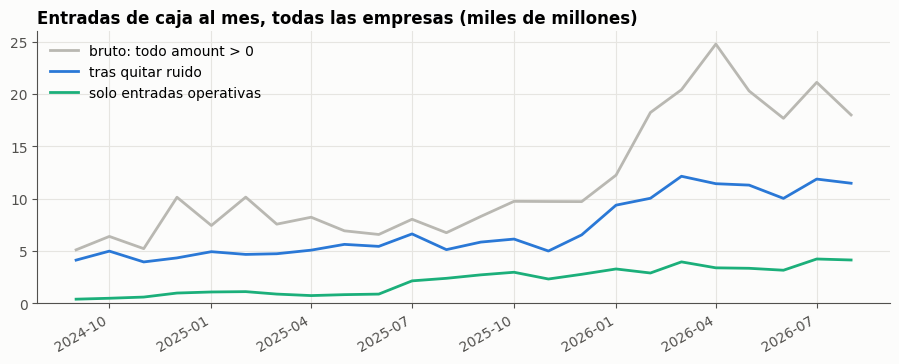

Entradas operativas / entradas brutas en todo el periodo: 18.6%


In [20]:
bruto = tx[(tx.amount > 0) & (tx.date < FECHA_EXTRACCION)].groupby("mes").amount.sum()
t_ok = tx_limpio[(tx_limpio.amount > 0) & (tx_limpio.date < FECHA_EXTRACCION)]
limpio_todo = t_ok.groupby("mes").amount.sum()
operativo = t_ok[(t_ok.bloque == "entrada_operativa") & ~t_ok.es_outlier & ~t_ok.es_intragrupo].groupby("mes").amount.sum()

fig, ax = plt.subplots(figsize=(11, 4))
for serie, lab, c in [(bruto, "bruto: todo amount > 0", MUTED), (limpio_todo, "tras quitar ruido", PAL[0]),
                      (operativo, "solo entradas operativas", PAL[2])]:
    ax.plot(serie.index.to_timestamp(), serie.values / 1e9, color=c, label=lab)
ax.set_title("Entradas de caja al mes, todas las empresas (miles de millones)")
ax.legend(frameon=False, loc="upper left"); ax.set_ylim(0)
fig.autofmt_xdate(); plt.show()
print(f"Entradas operativas / entradas brutas en todo el periodo: {pct(operativo.sum() / bruto.sum())}")

La serie bruta tiene picos que solo son outliers y traspasos. Tras la limpieza, las **entradas operativas son una fracción pequeña del importe bruto**: si se suma todo `amount > 0` sin limpiar, la mayor parte de lo que se mide no es negocio. Ojo: la tendencia creciente de las tres series sigue siendo el efecto onboarding del notebook 01, que se corrige al construir el panel por empresa.

## 7 · Resumen de reglas

| # | tabla | regla | acción |
|---|---|---|---|
| T1 | transactions | `amount == 0` | quitar |
| T2 | transactions | producto que no está en banking ni en debt | quitar |
| T3 | transactions | \|amount\| > 100 M | quitar |
| T4 | transactions | repeticiones en empresa-mes con ≥ 50% de filas duplicadas (sincronización doble) | quitar |
| T5 | transactions | `pending` con gemelo `booked` (±5 días) | quitar |
| T6 | transactions | \|amount\| > 20 × p99 de la empresa | marcar `es_outlier` |
| T7 | transactions | espejo +X/−X entre cuentas propias | marcar `es_traspaso_interno` |
| T8 | transactions | espejo +X/−X entre empresas del grupo | marcar `es_intragrupo` |
| T9 | transactions | categoría → bloque (operativo, gasto fijo, deuda, tesorería…) | nueva columna `bloque` |
| F1 | invoices | `amount == 0`, `status == cancel` | quitar |
| F2 | invoices | albaranes y pedidos | quitar |
| F3 | invoices | duplicados exactos (incluye contraparte y concepto) | quitar |
| F4 | invoices | `paymentDocument`, `deposit`, `other`, `cheque` | marcar `clase = dudoso` |
| F5 | invoices | plazo < 0 o > 365, vencimiento fuera de 2020–2030 | marcar `fechas_validas = False` |
| F6 | invoices | `payment_date` de relleno o futura | `payment_date_limpia = NaN` |
| F7 | invoices | `pending` vencida hace > 30 días | `status_limpio = overdue` |
| P1 | panel | meses fuera del rango de datos de la empresa | NaN (no 0) |
| P2 | panel | meses vacíos en medio de la historia | NaN + flag `hueco` |
| P3 | panel | empresa-mes con < 5 movimientos | flag `mes_fino` |
| P4 | panel | empresas con < 6 meses | fuera del entrenamiento |
| C1 | columnas | `country`, `label`, `service`, `available`, `countable`, `value_date`, `amortization_type`… | quitar (sección 2) |

**Preguntas para Embat:** ¿`amount` va en la moneda de la cuenta o en la original cuando `exchange_rate != 1`? ¿Las empresas que dejan de tener datos se han dado de baja o han cesado? ¿Qué significa `paymentDocument` en las facturas?